# Week 7 Outlier Detection and Data Quality

**IDX Exchange Data Analyst Internship**<br>
**Analysis period:** January 2024 through June 2026<br>
**Scope:** California Residential properties only

Summary of Week 7 outlier flags, filtering decisions, before-and-after market
measures, and final dataset validation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display


ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

OUTLIER_DIR = ROOT / "data" / "outliers"

COLORS = {
    "ink": "#1F2937",
    "teal": "#0F766E",
    "blue": "#1F6B8C",
    "amber": "#D97706",
    "red": "#B91C1C",
    "green": "#15803D",
    "gray": "#6B7280",
}

pd.set_option("display.max_columns", 30)

In [2]:
dataset_summary = pd.read_csv(
    OUTLIER_DIR / "week7_dataset_summary.csv"
)
thresholds = pd.read_csv(
    OUTLIER_DIR / "week7_iqr_thresholds.csv"
)
comparison = pd.read_csv(
    OUTLIER_DIR / "week7_before_after_comparison.csv"
)
flag_summary = pd.read_csv(
    OUTLIER_DIR / "week7_flag_summary.csv"
)
exclusion_reasons = pd.read_csv(
    OUTLIER_DIR / "week7_exclusion_reason_combinations.csv"
)
samples = pd.read_csv(
    OUTLIER_DIR / "week7_anonymized_flagged_sample.csv"
)
validation = pd.read_csv(
    OUTLIER_DIR / "week7_validation_summary.csv"
)

required_reports = {
    "dataset summary": dataset_summary,
    "thresholds": thresholds,
    "comparison": comparison,
    "flag summary": flag_summary,
    "exclusion reasons": exclusion_reasons,
    "samples": samples,
    "validation": validation,
}
assert all(not report.empty for report in required_reports.values())


def summary_value(dataset, field):
    match = dataset_summary[dataset_summary["Dataset"].eq(dataset)]
    if match.empty:
        raise KeyError(f"Missing dataset summary row: {dataset}")
    return match.iloc[0][field]


def dataset_label(value):
    return {
        "sold_residential": "Residential Sold",
        "listings_residential": "Residential Listings",
    }.get(value, value)


def metric_value(field, value):
    if pd.isna(value):
        return ""
    if field in {
        "ClosePrice",
        "ListPrice",
        "OriginalListPrice",
    }:
        return f"${value:,.0f}"
    if field == "PricePerSqFt":
        return f"${value:,.2f}"
    if field == "CloseToOriginalListRatio":
        return f"{value:.2%}"
    return f"{value:,.1f}"


print("Week 7 report inputs loaded successfully.")

Week 7 report inputs loaded successfully.


## Executive Summary

In [3]:
sold_input = int(summary_value("sold_residential", "InputRows"))
sold_clean = int(summary_value("sold_residential", "CleanOutputRows"))
sold_removed = int(
    summary_value("sold_residential", "AnalysisExcludedRows")
)
sold_removed_rate = float(
    summary_value("sold_residential", "AnalysisExcludedPercent")
)

listing_input = int(summary_value("listings_residential", "InputRows"))
listing_clean = int(
    summary_value("listings_residential", "CleanOutputRows")
)
listing_removed = int(
    summary_value("listings_residential", "AnalysisExcludedRows")
)
listing_removed_rate = float(
    summary_value("listings_residential", "AnalysisExcludedPercent")
)

snapshot_html = f'''
<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:14px;margin:8px 0 18px 0;">
  <div style="border-top:5px solid {COLORS["teal"]};padding:16px;background:#F7FAFA;">
    <div style="color:{COLORS["gray"]};font-size:13px;">Sold Rows Preserved</div>
    <div style="color:{COLORS["ink"]};font-size:28px;font-weight:700;">{sold_input:,}</div>
    <div style="color:{COLORS["gray"]};font-size:12px;">Full flagged dataset</div>
  </div>
  <div style="border-top:5px solid {COLORS["blue"]};padding:16px;background:#F7F9FB;">
    <div style="color:{COLORS["gray"]};font-size:13px;">Clean Sold Rows</div>
    <div style="color:{COLORS["ink"]};font-size:28px;font-weight:700;">{sold_clean:,}</div>
    <div style="color:{COLORS["gray"]};font-size:12px;">{sold_removed_rate:.1%} excluded</div>
  </div>
  <div style="border-top:5px solid {COLORS["teal"]};padding:16px;background:#F7FAFA;">
    <div style="color:{COLORS["gray"]};font-size:13px;">Listing Rows Preserved</div>
    <div style="color:{COLORS["ink"]};font-size:28px;font-weight:700;">{listing_input:,}</div>
    <div style="color:{COLORS["gray"]};font-size:12px;">Full flagged dataset</div>
  </div>
  <div style="border-top:5px solid {COLORS["blue"]};padding:16px;background:#F7F9FB;">
    <div style="color:{COLORS["gray"]};font-size:13px;">Clean Listing Rows</div>
    <div style="color:{COLORS["ink"]};font-size:28px;font-weight:700;">{listing_clean:,}</div>
    <div style="color:{COLORS["gray"]};font-size:12px;">{listing_removed_rate:.1%} excluded</div>
  </div>
</div>
'''
display(HTML(snapshot_html))

### Dataset Outcome

- Full flagged datasets preserve all Week 6 records.
- Clean datasets exclude core outliers, invalid values, negative timeline
  intervals, and extreme review-field outliers.
- Clean datasets are prepared for Tableau analysis; flagged datasets remain
  the audit source.

## Rules Applied

In [4]:
method = pd.DataFrame(
    [
        {
            "Rule Group": "Invalid values",
            "Fields": (
                "Numeric business rules and negative date intervals"
            ),
            "Rule": (
                "Price/area/ratio must be positive; days must be "
                "nonnegative; timeline intervals cannot be negative"
            ),
            "Result": "Excluded",
        },
        {
            "Rule Group": "Core 1.5 IQR",
            "Fields": (
                "Sold: ClosePrice, LivingArea, DaysOnMarket; "
                "Listings: ListPrice, LivingArea, DaysOnMarket"
            ),
            "Rule": "Outside Q1 - 1.5 x IQR or Q3 + 1.5 x IQR",
            "Result": "Excluded",
        },
        {
            "Rule Group": "Review 1.5 IQR",
            "Fields": (
                "Sold: PricePerSqFt, CloseToOriginalListRatio; "
                "Listings: OriginalListPrice"
            ),
            "Rule": "Outside the 1.5 IQR boundary",
            "Result": "Flagged and retained",
        },
        {
            "Rule Group": "Extreme review 3.0 IQR",
            "Fields": "Review fields",
            "Rule": "Outside Q1 - 3.0 x IQR or Q3 + 3.0 x IQR",
            "Result": "Excluded",
        },
    ]
)

display(method.style.hide(axis="index"))

Rule Group,Fields,Rule,Result
Invalid values,Numeric business rules and negative date intervals,Price/area/ratio must be positive; days must be nonnegative; timeline intervals cannot be negative,Excluded
Core 1.5 IQR,"Sold: ClosePrice, LivingArea, DaysOnMarket; Listings: ListPrice, LivingArea, DaysOnMarket",Outside Q1 - 1.5 x IQR or Q3 + 1.5 x IQR,Excluded
Review 1.5 IQR,"Sold: PricePerSqFt, CloseToOriginalListRatio; Listings: OriginalListPrice",Outside the 1.5 IQR boundary,Flagged and retained
Extreme review 3.0 IQR,Review fields,Outside Q1 - 3.0 x IQR or Q3 + 3.0 x IQR,Excluded


## IQR Thresholds

In [5]:
threshold_display = thresholds[
    [
        "Dataset",
        "Field",
        "Role",
        "Q1",
        "Q3",
        "LowerBound",
        "UpperBound",
        "ExtremeLowerBound",
        "ExtremeUpperBound",
    ]
].copy()
threshold_display["Dataset"] = threshold_display["Dataset"].map(
    dataset_label
)
threshold_display["Role"] = threshold_display["Role"].map(
    {
        "core_filter": "Core: filter at 1.5 IQR",
        "review_only": "Review at 1.5; filter at 3.0 IQR",
    }
)

for column in [
    "Q1",
    "Q3",
    "LowerBound",
    "UpperBound",
    "ExtremeLowerBound",
    "ExtremeUpperBound",
]:
    threshold_display[column] = [
        metric_value(field, value)
        for field, value in zip(
            threshold_display["Field"],
            threshold_display[column],
        )
    ]

threshold_display.columns = [
    "Dataset",
    "Field",
    "Treatment",
    "Q1",
    "Q3",
    "1.5 IQR Lower",
    "1.5 IQR Upper",
    "3.0 IQR Lower",
    "3.0 IQR Upper",
]

display(threshold_display.style.hide(axis="index"))

Dataset,Field,Treatment,Q1,Q3,1.5 IQR Lower,1.5 IQR Upper,3.0 IQR Lower,3.0 IQR Upper
Residential Sold,ClosePrice,Core: filter at 1.5 IQR,"$575,000","$1,300,000","$-512,500","$2,387,500","$-1,600,000","$3,475,000"
Residential Sold,LivingArea,Core: filter at 1.5 IQR,"1,248.0","2,224.0",-216.0,"3,688.0","-1,680.0","5,152.0"
Residential Sold,DaysOnMarket,Core: filter at 1.5 IQR,8.0,48.0,-52.0,108.0,-112.0,168.0
Residential Sold,PricePerSqFt,Review at 1.5; filter at 3.0 IQR,$368.03,$732.60,$-178.83,"$1,279.46",$-725.69,"$1,826.32"
Residential Sold,CloseToOriginalListRatio,Review at 1.5; filter at 3.0 IQR,95.37%,101.94%,85.53%,111.78%,75.68%,121.63%
Residential Listings,ListPrice,Core: filter at 1.5 IQR,"$583,000","$1,388,000","$-624,500","$2,595,500","$-1,832,000","$3,803,000"
Residential Listings,LivingArea,Core: filter at 1.5 IQR,"1,248.0","2,303.0",-334.5,"3,885.5","-1,917.0","5,468.0"
Residential Listings,DaysOnMarket,Core: filter at 1.5 IQR,5.0,21.0,-19.0,45.0,-43.0,69.0
Residential Listings,OriginalListPrice,Review at 1.5; filter at 3.0 IQR,"$585,000","$1,395,000","$-630,000","$2,610,000","$-1,845,000","$3,825,000"


## Flag Summary

In [6]:
flag_display = flag_summary.copy()
flag_display["Dataset"] = flag_display["Dataset"].map(dataset_label)
flag_display["Flag Type"] = flag_display["FlagType"].map(
    {
        "IQR": "1.5 IQR",
        "Extreme IQR": "3.0 IQR extreme",
        "Business Rule": "Business rule",
        "Date Sequence": "Date sequence",
    }
)
flag_display["Clean Dataset Treatment"] = flag_display[
    "UsedToExcludeFromCleanDataset"
].map({True: "Exclude", False: "Review only"})
flag_display = flag_display[
    [
        "Dataset",
        "Flag Type",
        "Field",
        "FlaggedRows",
        "FlaggedPercent",
        "Clean Dataset Treatment",
    ]
]
flag_display.columns = [
    "Dataset",
    "Flag Type",
    "Field",
    "Flagged Rows",
    "Percent of Dataset",
    "Clean Dataset Treatment",
]

display(
    flag_display.style
    .hide(axis="index")
    .format(
        {
            "Flagged Rows": "{:,.0f}",
            "Percent of Dataset": "{:.2%}",
        }
    )
)

Dataset,Flag Type,Field,Flagged Rows,Percent of Dataset,Clean Dataset Treatment
Residential Sold,1.5 IQR,ClosePrice,"33,536",7.49%,Exclude
Residential Sold,1.5 IQR,LivingArea,"19,562",4.37%,Exclude
Residential Sold,1.5 IQR,DaysOnMarket,"34,152",7.63%,Exclude
Residential Sold,1.5 IQR,PricePerSqFt,"18,912",4.22%,Review only
Residential Sold,3.0 IQR extreme,PricePerSqFt,"5,191",1.16%,Exclude
Residential Sold,1.5 IQR,CloseToOriginalListRatio,"42,531",9.50%,Review only
Residential Sold,3.0 IQR extreme,CloseToOriginalListRatio,"12,837",2.87%,Exclude
Residential Listings,1.5 IQR,ListPrice,"51,115",8.30%,Exclude
Residential Listings,1.5 IQR,LivingArea,"30,333",4.93%,Exclude
Residential Listings,1.5 IQR,DaysOnMarket,"49,155",7.98%,Exclude


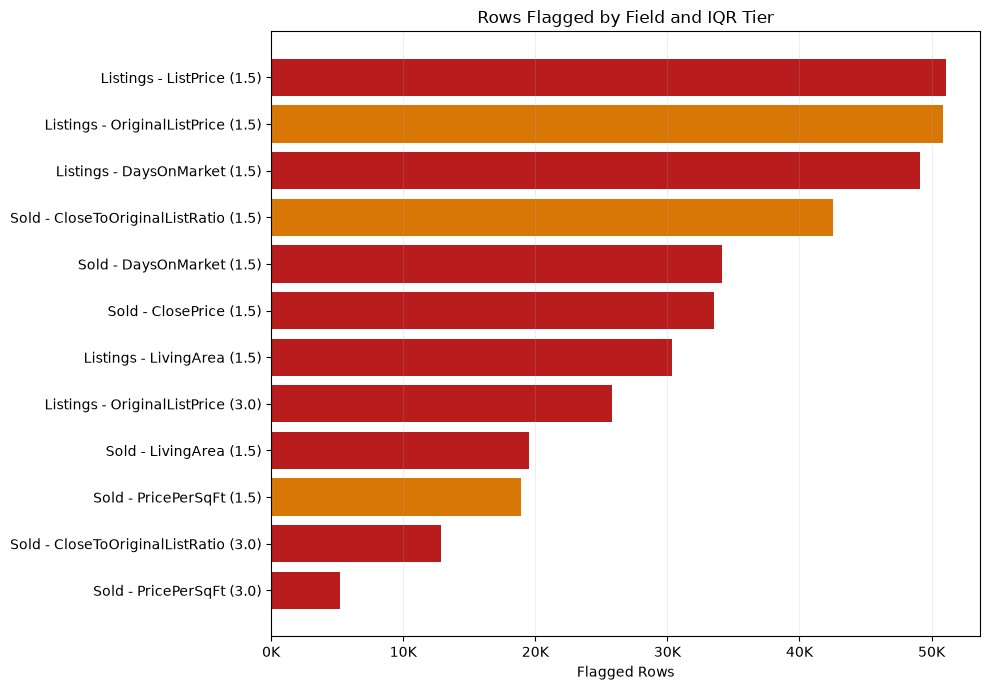

In [7]:
chart_flags = flag_summary[
    flag_summary["FlagType"].isin(["IQR", "Extreme IQR"])
].copy()
chart_flags["Label"] = (
    chart_flags["Dataset"].map(
        {
            "sold_residential": "Sold",
            "listings_residential": "Listings",
        }
    )
    + " - "
    + chart_flags["Field"]
    + chart_flags["FlagType"].map(
        {"IQR": " (1.5)", "Extreme IQR": " (3.0)"}
    )
)
chart_flags = chart_flags.sort_values("FlaggedRows")

fig, ax = plt.subplots(figsize=(10, 7))
colors = chart_flags["UsedToExcludeFromCleanDataset"].map(
    {True: COLORS["red"], False: COLORS["amber"]}
)
ax.barh(
    chart_flags["Label"],
    chart_flags["FlaggedRows"],
    color=colors,
)
ax.set_title("Rows Flagged by Field and IQR Tier")
ax.set_xlabel("Flagged Rows")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000:.0f}K")
)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### Invalid Values and Date Sequences

In [8]:
quality_rows = flag_summary[
    flag_summary["FlagType"].isin(
        ["Business Rule", "Date Sequence"]
    )
].copy()
quality_rows["Dataset"] = quality_rows["Dataset"].map(dataset_label)
quality_rows = quality_rows[
    ["Dataset", "FlagType", "FlaggedRows", "FlaggedPercent"]
]
quality_rows.columns = [
    "Dataset",
    "Problem Type",
    "Rows",
    "Percent of Dataset",
]
display(
    quality_rows.style
    .hide(axis="index")
    .format({"Rows": "{:,.0f}", "Percent of Dataset": "{:.3%}"})
)

Dataset,Problem Type,Rows,Percent of Dataset
Residential Sold,Business Rule,0,0.000%
Residential Sold,Date Sequence,529,0.118%
Residential Listings,Business Rule,4,0.001%
Residential Listings,Date Sequence,568,0.092%


## Before and After

In [9]:
impact = dataset_summary[
    [
        "Dataset",
        "InputRows",
        "CleanOutputRows",
        "AnalysisExcludedRows",
        "AnalysisExcludedPercent",
    ]
].copy()
impact["Dataset"] = impact["Dataset"].map(dataset_label)
impact["RetentionPercent"] = (
    impact["CleanOutputRows"] / impact["InputRows"]
)
impact.columns = [
    "Dataset",
    "Before Rows",
    "Clean Rows",
    "Excluded Rows",
    "Excluded Percent",
    "Retained Percent",
]
display(
    impact.style
    .hide(axis="index")
    .format(
        {
            "Before Rows": "{:,.0f}",
            "Clean Rows": "{:,.0f}",
            "Excluded Rows": "{:,.0f}",
            "Excluded Percent": "{:.1%}",
            "Retained Percent": "{:.1%}",
        }
    )
)

Dataset,Before Rows,Clean Rows,Excluded Rows,Excluded Percent,Retained Percent
Residential Sold,"447,850","367,952","79,898",17.8%,82.2%
Residential Listings,"615,671","511,301","104,370",17.0%,83.0%


In [10]:
comparison_display = comparison.copy()
comparison_display["Dataset"] = comparison_display["Dataset"].map(
    dataset_label
)
comparison_display["Before Median"] = [
    metric_value(field, value)
    for field, value in zip(
        comparison_display["Field"],
        comparison_display["BeforeMedian"],
    )
]
comparison_display["After Median"] = [
    metric_value(field, value)
    for field, value in zip(
        comparison_display["Field"],
        comparison_display["AfterMedian"],
    )
]
comparison_display["Median Change"] = comparison_display[
    "MedianChangePercent"
]
comparison_display = comparison_display[
    [
        "Dataset",
        "Field",
        "Before Median",
        "After Median",
        "Median Change",
    ]
]

display(
    comparison_display.style
    .hide(axis="index")
    .format({"Median Change": "{:+.1%}"})
)

Dataset,Field,Before Median,After Median,Median Change
Residential Sold,ClosePrice,"$825,000","$780,000",-5.5%
Residential Sold,LivingArea,"1,646.0","1,575.0",-4.3%
Residential Sold,DaysOnMarket,18.0,16.0,-11.1%
Residential Sold,PricePerSqFt,$537.33,$524.06,-2.5%
Residential Sold,CloseToOriginalListRatio,99.57%,100.00%,+0.4%
Residential Listings,ListPrice,"$849,000","$799,000",-5.9%
Residential Listings,LivingArea,"1,672.0","1,587.0",-5.1%
Residential Listings,DaysOnMarket,10.0,9.0,-10.0%
Residential Listings,OriginalListPrice,"$849,000","$799,000",-5.9%


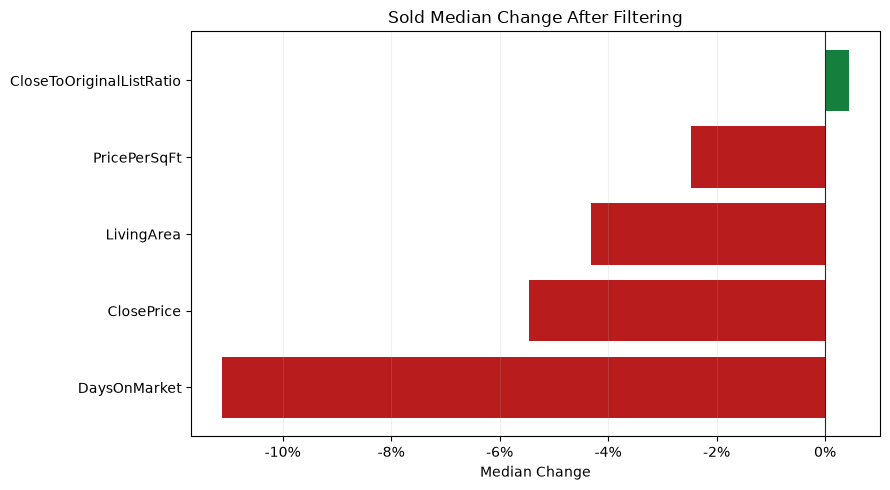

In [11]:
sold_change = comparison[
    comparison["Dataset"].eq("sold_residential")
].copy()
sold_change = sold_change.sort_values("MedianChangePercent")

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [
    COLORS["red"] if value < 0 else COLORS["green"]
    for value in sold_change["MedianChangePercent"]
]
ax.barh(
    sold_change["Field"],
    sold_change["MedianChangePercent"] * 100,
    color=bar_colors,
)
ax.axvline(0, color=COLORS["ink"], linewidth=0.8)
ax.set_title("Sold Median Change After Filtering")
ax.set_xlabel("Median Change")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0f}%")
)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

In [12]:
ratio_row = comparison[
    comparison["Dataset"].eq("sold_residential")
    & comparison["Field"].eq("CloseToOriginalListRatio")
].iloc[0]

ratio_html = f'''
<div style="border-left:5px solid {COLORS["red"]};padding:14px 18px;background:#FFF7F7;margin:8px 0 18px 0;">
  <div style="font-weight:700;color:{COLORS["ink"]};">Close-to-Original-List Ratio Result</div>
  <div style="margin-top:6px;">
    Unfiltered average: <strong>{ratio_row["BeforeMean"]:.2%}</strong>.
    Filtered average: <strong>{ratio_row["AfterMean"]:.2%}</strong>.
    Filtered median: <strong>{ratio_row["AfterMedian"]:.2%}</strong>.
  </div>
</div>
'''
display(HTML(ratio_html))

## Flagged Record Summary

### Largest Recorded Values

Maximums, 99th percentiles, and filtering boundaries for sold metrics.

In [13]:
extreme_display = thresholds[
    thresholds["Dataset"].eq("sold_residential")
][
    [
        "Field",
        "Maximum",
        "P99",
        "UpperBound",
        "ExtremeUpperBound",
    ]
].copy()
for column in ["Maximum", "P99", "UpperBound", "ExtremeUpperBound"]:
    extreme_display[column] = [
        metric_value(field, value)
        for field, value in zip(
            extreme_display["Field"],
            extreme_display[column],
        )
    ]
extreme_display.columns = [
    "Sold Field",
    "Recorded Maximum",
    "99th Percentile",
    "1.5 IQR Upper",
    "3.0 IQR Upper",
]
display(extreme_display.style.hide(axis="index"))

Sold Field,Recorded Maximum,99th Percentile,1.5 IQR Upper,3.0 IQR Upper
ClosePrice,"$989,500,000","$5,600,000","$2,387,500","$3,475,000"
LivingArea,"17,021,321.0","5,288.0","3,688.0","5,152.0"
DaysOnMarket,"12,430.0",233.0,108.0,168.0
PricePerSqFt,"$1,164,066.85","$1,895.34","$1,279.46","$1,826.32"
CloseToOriginalListRatio,911800000.00%,128.48%,111.78%,121.63%


### Anonymized Flagged Examples

Eight sold records with the highest number of simultaneous flags. Identifying
fields are excluded.

In [14]:
sold_samples = samples[
    samples["Dataset"].eq("sold_residential")
][
    [
        "PropertySubType",
        "CountyOrParish",
        "ClosePrice",
        "LivingArea",
        "DaysOnMarket",
        "PricePerSqFt",
        "CloseToOriginalListRatio",
        "OutlierFlagCount",
        "OutlierReason",
    ]
].head(8)

display(
    sold_samples.style
    .hide(axis="index")
    .format(
        {
            "ClosePrice": "${:,.0f}",
            "LivingArea": "{:,.0f}",
            "DaysOnMarket": "{:,.0f}",
            "PricePerSqFt": "${:,.2f}",
            "CloseToOriginalListRatio": "{:.2%}",
            "OutlierFlagCount": "{:,.0f}",
        },
        na_rep="",
    )
)

PropertySubType,CountyOrParish,ClosePrice,LivingArea,DaysOnMarket,PricePerSqFt,CloseToOriginalListRatio,OutlierFlagCount,OutlierReason
SingleFamilyResidence,Orange,"$11,350,000","4,160",181,"$2,728.37",70.96%,5,ClosePrice outside 1.5 IQR; LivingArea outside 1.5 IQR; DaysOnMarket outside 1.5 IQR; PricePerSqFt outside 1.5 IQR; CloseToOriginalListRatio outside 1.5 IQR
SingleFamilyResidence,Santa Barbara,"$5,900,000","3,767",217,"$1,566.23",69.41%,5,ClosePrice outside 1.5 IQR; LivingArea outside 1.5 IQR; DaysOnMarket outside 1.5 IQR; PricePerSqFt outside 1.5 IQR; CloseToOriginalListRatio outside 1.5 IQR
SingleFamilyResidence,Los Angeles,"$9,900,000","5,540",249,"$1,787.00",83.19%,5,ClosePrice outside 1.5 IQR; LivingArea outside 1.5 IQR; DaysOnMarket outside 1.5 IQR; PricePerSqFt outside 1.5 IQR; CloseToOriginalListRatio outside 1.5 IQR
SingleFamilyResidence,Los Angeles,"$12,700,000","3,989",171,"$3,183.76",68.65%,5,ClosePrice outside 1.5 IQR; LivingArea outside 1.5 IQR; DaysOnMarket outside 1.5 IQR; PricePerSqFt outside 1.5 IQR; CloseToOriginalListRatio outside 1.5 IQR
SingleFamilyResidence,Santa Barbara,"$6,780,000","4,634",175,"$1,463.10",85.28%,5,ClosePrice outside 1.5 IQR; LivingArea outside 1.5 IQR; DaysOnMarket outside 1.5 IQR; PricePerSqFt outside 1.5 IQR; CloseToOriginalListRatio outside 1.5 IQR
Condominium,San Diego,"$7,450,000","4,643",110,"$1,604.57",82.79%,5,ClosePrice outside 1.5 IQR; LivingArea outside 1.5 IQR; DaysOnMarket outside 1.5 IQR; PricePerSqFt outside 1.5 IQR; CloseToOriginalListRatio outside 1.5 IQR
SingleFamilyResidence,Orange,"$10,200,000","5,150",202,"$1,980.58",81.63%,5,ClosePrice outside 1.5 IQR; LivingArea outside 1.5 IQR; DaysOnMarket outside 1.5 IQR; PricePerSqFt outside 1.5 IQR; CloseToOriginalListRatio outside 1.5 IQR
SingleFamilyResidence,Los Angeles,"$18,000,000","7,473",351,"$2,408.67",72.01%,5,ClosePrice outside 1.5 IQR; LivingArea outside 1.5 IQR; DaysOnMarket outside 1.5 IQR; PricePerSqFt outside 1.5 IQR; CloseToOriginalListRatio outside 1.5 IQR


### Most Common Analysis Exclusion Combinations

In [15]:
top_exclusions = (
    exclusion_reasons.sort_values(
        ["Dataset", "Rows"],
        ascending=[True, False],
    )
    .groupby("Dataset", group_keys=False)
    .head(8)
    .copy()
)
top_exclusions["Dataset"] = top_exclusions["Dataset"].map(dataset_label)
top_exclusions.columns = [
    "Dataset",
    "Exclusion Reason Combination",
    "Rows",
]
display(
    top_exclusions.style
    .hide(axis="index")
    .format({"Rows": "{:,.0f}"})
)

Dataset,Exclusion Reason Combination,Rows
Residential Listings,DaysOnMarket outside 1.5 IQR,"43,734"
Residential Listings,ListPrice outside 1.5 IQR,"17,968"
Residential Listings,ListPrice outside 1.5 IQR; LivingArea outside 1.5 IQR; OriginalListPrice outside 3.0 IQR extreme fence,"13,614"
Residential Listings,ListPrice outside 1.5 IQR; OriginalListPrice outside 3.0 IQR extreme fence,"9,184"
Residential Listings,LivingArea outside 1.5 IQR,"7,721"
Residential Listings,ListPrice outside 1.5 IQR; LivingArea outside 1.5 IQR,"5,789"
Residential Listings,ListPrice outside 1.5 IQR; LivingArea outside 1.5 IQR; DaysOnMarket outside 1.5 IQR; OriginalListPrice outside 3.0 IQR extreme fence,"1,632"
Residential Listings,ListPrice outside 1.5 IQR; DaysOnMarket outside 1.5 IQR,"1,279"
Residential Sold,DaysOnMarket outside 1.5 IQR,"27,362"
Residential Sold,ClosePrice outside 1.5 IQR,"15,560"


## Validation

Row preservation, listing-key order, clean-file membership, and source-total
reconciliation checks.

In [16]:
validation_display = validation.copy()
validation_display["Dataset"] = validation_display["Dataset"].map(
    dataset_label
)
validation_display = validation_display[
    [
        "Dataset",
        "ExpectedSourceRows",
        "CheckedFlaggedRows",
        "CheckedCleanRows",
        "FlaggedListingKeyOrderErrors",
        "CleanRowsStillMarkedForExclusion",
        "FlaggedRowsPreserved",
        "CleanRowsCorrect",
        "CleanPlusExcludedReconciles",
    ]
]
validation_display.columns = [
    "Dataset",
    "Source Rows",
    "Flagged Rows",
    "Clean Rows",
    "Key/Order Errors",
    "Excluded Rows in Clean File",
    "Flagged Preserved",
    "Clean Correct",
    "Totals Reconcile",
]

display(
    validation_display.style
    .hide(axis="index")
    .format(
        {
            "Source Rows": "{:,.0f}",
            "Flagged Rows": "{:,.0f}",
            "Clean Rows": "{:,.0f}",
            "Key/Order Errors": "{:,.0f}",
            "Excluded Rows in Clean File": "{:,.0f}",
        }
    )
)

Dataset,Source Rows,Flagged Rows,Clean Rows,Key/Order Errors,Excluded Rows in Clean File,Flagged Preserved,Clean Correct,Totals Reconcile
Residential Sold,"447,850","447,850","367,952",0,0,True,True,True
Residential Listings,"615,671","615,671","511,301",0,0,True,True,True


## Week 7 Outputs

### Full Audit Datasets

- `sold_residential_outlier_flagged.csv`
- `listings_residential_outlier_flagged.csv`

### Analysis-Ready Datasets

- `sold_residential_analysis_clean.csv`
- `listings_residential_analysis_clean.csv`

### Supporting Reports

- `week7_iqr_thresholds.csv`
- `week7_dataset_summary.csv`
- `week7_flag_summary.csv`
- `week7_before_after_comparison.csv`
- `week7_exclusion_reason_combinations.csv`
- `week7_reason_combinations.csv`
- `week7_anonymized_flagged_sample.csv`
- `week7_validation_summary.csv`

Flagged datasets are the audit source. Clean datasets are the Week 7
analysis-ready outputs.

## Source

- IDX Exchange Data Analyst Internship Handbook, Week 7
- Week 6 California Residential feature-ready listing and sold datasets